<a href="https://colab.research.google.com/github/inte11ectua1/-/blob/main/Sudakov_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

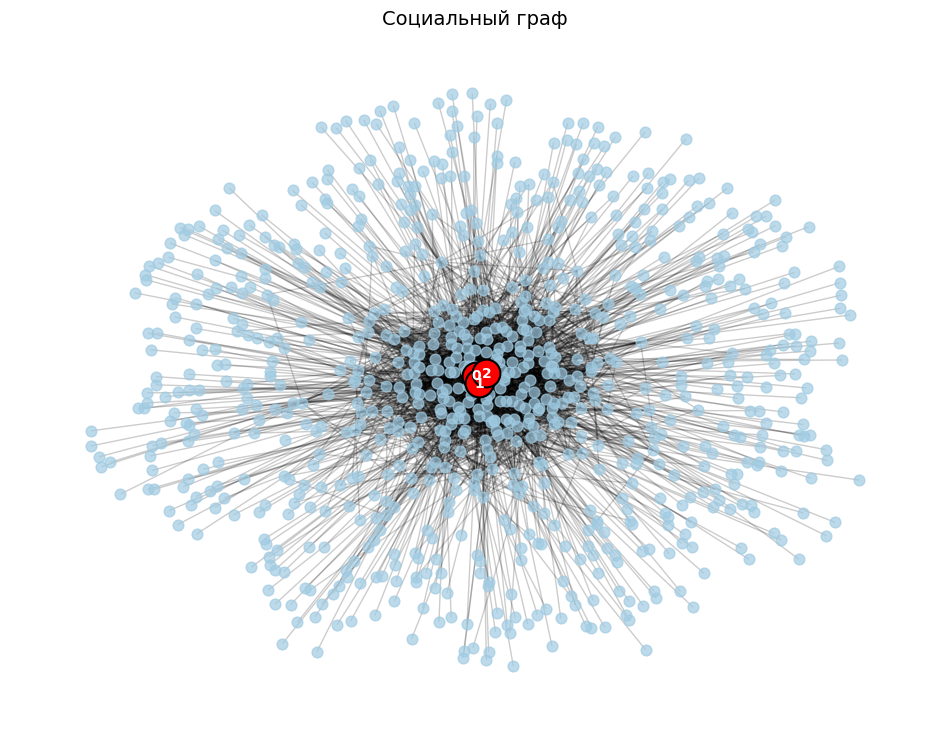

In [11]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("social_network_dataset_v2.csv")

# Создаём граф и выделяем основных пользователей
G = nx.from_pandas_edgelist(df, source="user_id", target="friend_id")
base_users = [0, 1, 2]

plt.figure(figsize=(12, 9))
pos = nx.spring_layout(G, seed=42, k=0.15)

# Сначала отрисовываем всех, кроме основных
nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=[n for n in G.nodes() if n not in base_users],
    node_color="#A0CBE2",
    node_size=60,
    alpha=0.7,
)
nx.draw_networkx_edges(G, pos, alpha=0.2)

# Поверх отрисовываем основных
nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=base_users,
    node_color="red",
    node_size=400,
    edgecolors="black",
    linewidths=1.5,
)

# Добавляем подписи для основных
nx.draw_networkx_labels(G, pos, labels={n: n for n in base_users}, font_color="white", font_size=10, font_weight="bold")

plt.title("Социальный граф", fontsize=14)
plt.axis("off")
plt.show()

In [12]:
# Центральность по посредничеству
def betweenness_centrality_manual(G):
    nodes = list(G.nodes())
    betweenness = dict.fromkeys(nodes, 0.0)

    for s in nodes:
        stack = []
        pred = {w: [] for w in nodes}
        sigma = dict.fromkeys(nodes, 0.0)
        sigma[s] = 1.0
        dist = dict.fromkeys(nodes, -1)
        dist[s] = 0
        queue = [s]
        while queue:
            v = queue.pop(0)
            stack.append(v)
            for w in G.neighbors(v):
                if dist[w] < 0:
                    queue.append(w)
                    dist[w] = dist[v] + 1
                if dist[w] == dist[v] + 1:
                    sigma[w] += sigma[v]
                    pred[w].append(v)
        delta = dict.fromkeys(nodes, 0.0)
        while stack:
            w = stack.pop()
            for v in pred[w]:
                delta[v] += (sigma[v] / sigma[w]) * (1 + delta[w])
            if w != s:
                betweenness[w] += delta[w]

    # Нормализация
    n = len(nodes)
    if n > 2:
        scale = 1 / ((n - 1) * (n - 2))
        for v in betweenness:
            betweenness[v] *= scale
    return betweenness
betw = betweenness_centrality_manual(G)

In [13]:
# Центральность по близости
def closeness_centrality_manual(G):
    closeness = {}
    for node in G.nodes():
        lengths = nx.single_source_shortest_path_length(G, node)
        total_dist = sum(lengths.values())
        if total_dist > 0:
            closeness[node] = (len(lengths) - 1) / total_dist
        else:
            closeness[node] = 0.0
    return closeness
close = closeness_centrality_manual(G)

In [14]:
# Центральность по собственному вектору
def eigenvector_centrality_manual(G, max_iter=100, tol=1e-6):
    n = len(G)
    x = np.ones(n)
    nodes = list(G.nodes())
    A = nx.to_numpy_array(G, nodelist=nodes)

    for _ in range(max_iter):
        x_new = A @ x
        x_new /= np.linalg.norm(x_new)
        if np.linalg.norm(x_new - x) < tol:
            break
        x = x_new

    return {nodes[i]: x[i] for i in range(n)}
eig = eigenvector_centrality_manual(G)

In [15]:
# Таблица центральностей для основных пользователей
results = pd.DataFrame({
    "user_id": base_users,
    "betweenness": [betw[u] for u in base_users],
    "closeness": [close[u] for u in base_users],
    "eigenvector": [eig[u] for u in base_users]
})

print("\nЦентральности для основных пользователей (0, 1, 2):")
print(results)


Центральности для основных пользователей (0, 1, 2):
   user_id  betweenness  closeness  eigenvector
0        0     0.169485   0.482173     0.284917
1        1     0.192317   0.489655     0.351364
2        2     0.182274   0.486857     0.331638
